In [1]:
import pandas as pd
import numpy as np

train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

In [2]:
train_df.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


In [3]:
train_df.describe()

,id,age,study_hours,class_attendance,sleep_hours,exam_score
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,20.545821,4.002337,71.987261,7.072758,62.506672
std,181865.479132,2.260238,2.359880,17.430098,1.744811,18.916884
min,0.000000,17.000000,0.080000,40.600000,4.100000,19.599000
25%,157499.750000,19.000000,1.970000,57.000000,5.600000,48.800000
50%,314999.500000,21.000000,4.000000,72.600000,7.100000,62.600000
75%,472499.250000,23.000000,6.050000,87.200000,8.600000,76.300000
max,629999.000000,24.000000,7.910000,99.400000,9.900000,100.000000


In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                630000 non-null  int64  
 1   age               630000 non-null  int64  
 2   gender            630000 non-null  object 
 3   course            630000 non-null  object 
 4   study_hours       630000 non-null  float64
 5   class_attendance  630000 non-null  float64
 6   internet_access   630000 non-null  object 
 7   sleep_hours       630000 non-null  float64
 8   sleep_quality     630000 non-null  object 
 9   study_method      630000 non-null  object 
 10  facility_rating   630000 non-null  object 
 11  exam_difficulty   630000 non-null  object 
 12  exam_score        630000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 62.5+ MB


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# 그래프 스타일 설정
plt.style.use('ggplot')
sns.set_palette("husl")

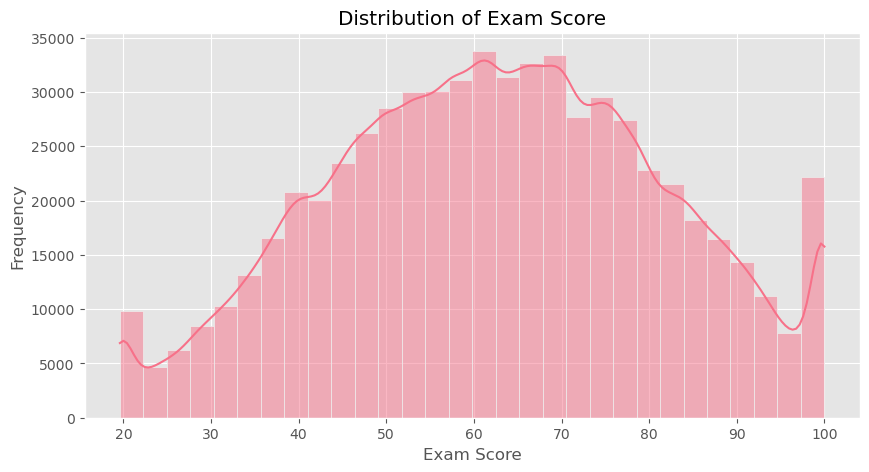

In [6]:
# 1. 타겟 변수(exam_score)의 분포 확인
# 점수가 어느 쪽에 몰려 있는지, 이상치는 없는지 확인
plt.figure(figsize=(10, 5))
sns.histplot(train_df['exam_score'], kde=True, bins=30)
plt.title('Distribution of Exam Score')
plt.xlabel('Exam Score')
plt.ylabel('Frequency')
plt.show()

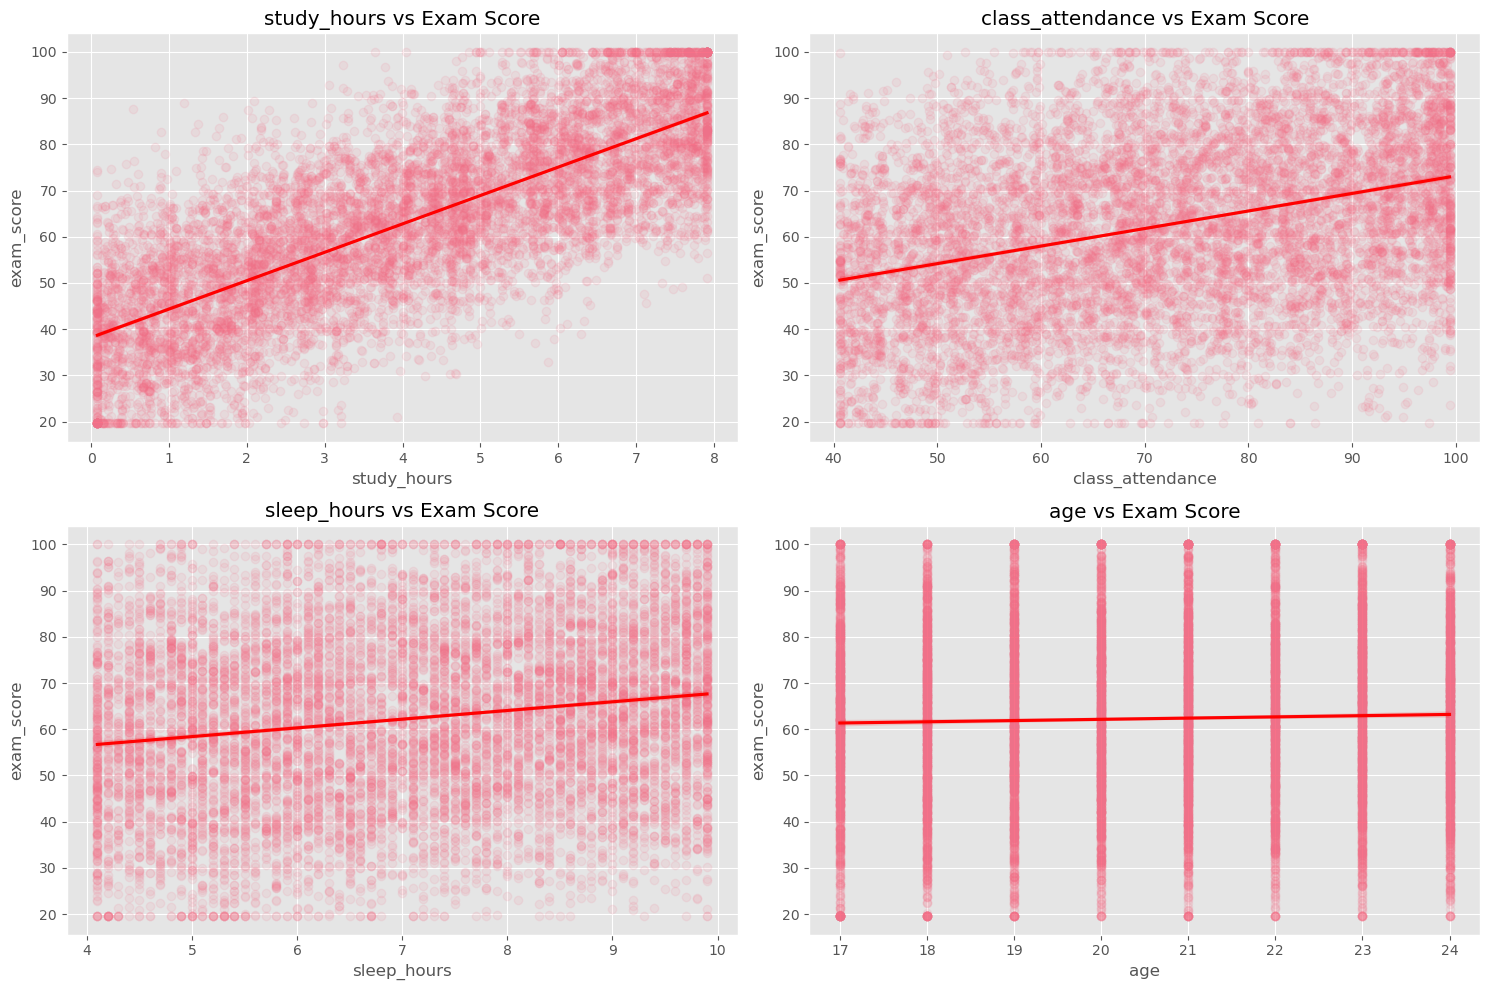

In [7]:
# 2. 수치형 변수 vs 타겟 변수의 관계 (상관관계)
# 어떤 공부 습관이 점수에 직접적인 영향을 주는지 산점도로 확인
num_features = ['study_hours', 'class_attendance', 'sleep_hours', 'age']

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_features, 1):
    plt.subplot(2, 2, i)
    # 데이터가 많으므로 scatter 대신 regplot으로 추세선을 봅니다. (샘플링 10,000개)
    sns.regplot(data=train_df.sample(10000), x=col, y='exam_score', 
                scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
    plt.title(f'{col} vs Exam Score')
plt.tight_layout()
plt.show()

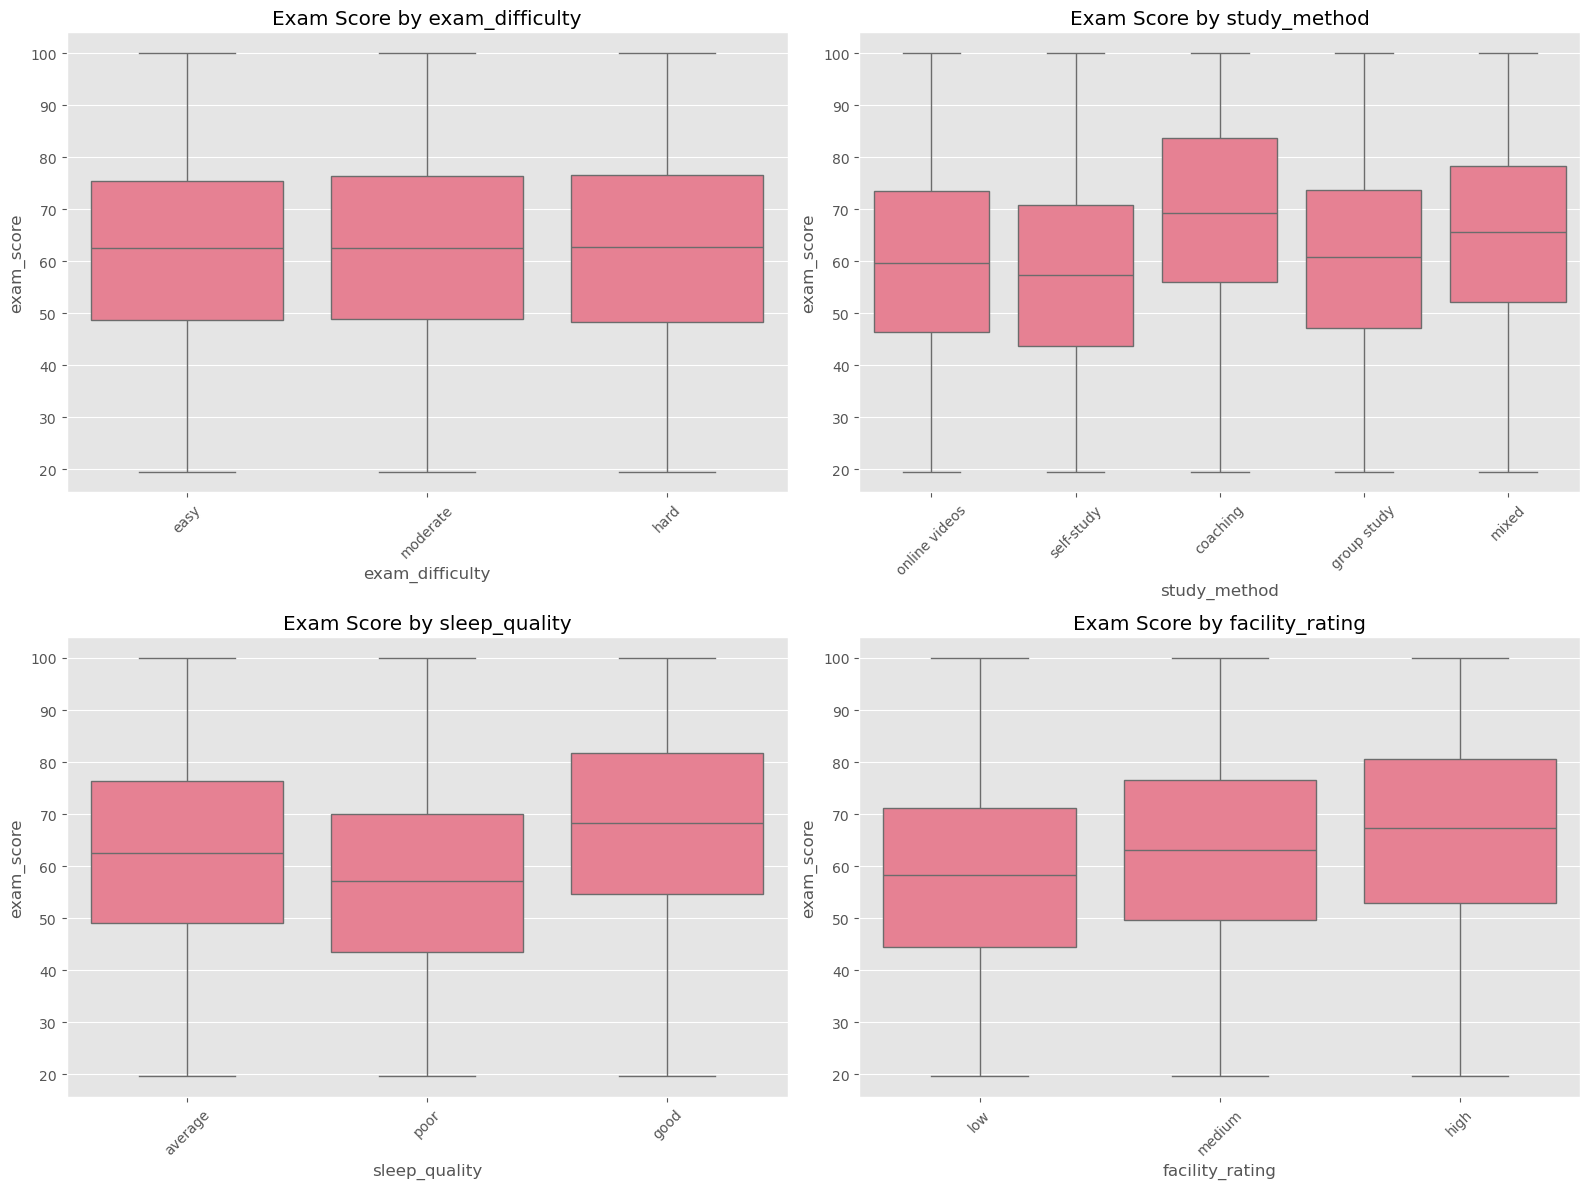

In [8]:
# 3. 범주형 변수 분석 (Boxplot)
# '난이도'나 '공부 방법'에 따라 점수 차이가 극명한지 확인
cat_features = ['exam_difficulty', 'study_method', 'sleep_quality', 'facility_rating']

plt.figure(figsize=(16, 12))
for i, col in enumerate(cat_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=train_df, x=col, y='exam_score')
    plt.xticks(rotation=45)
    plt.title(f'Exam Score by {col}')
plt.tight_layout()
plt.show()

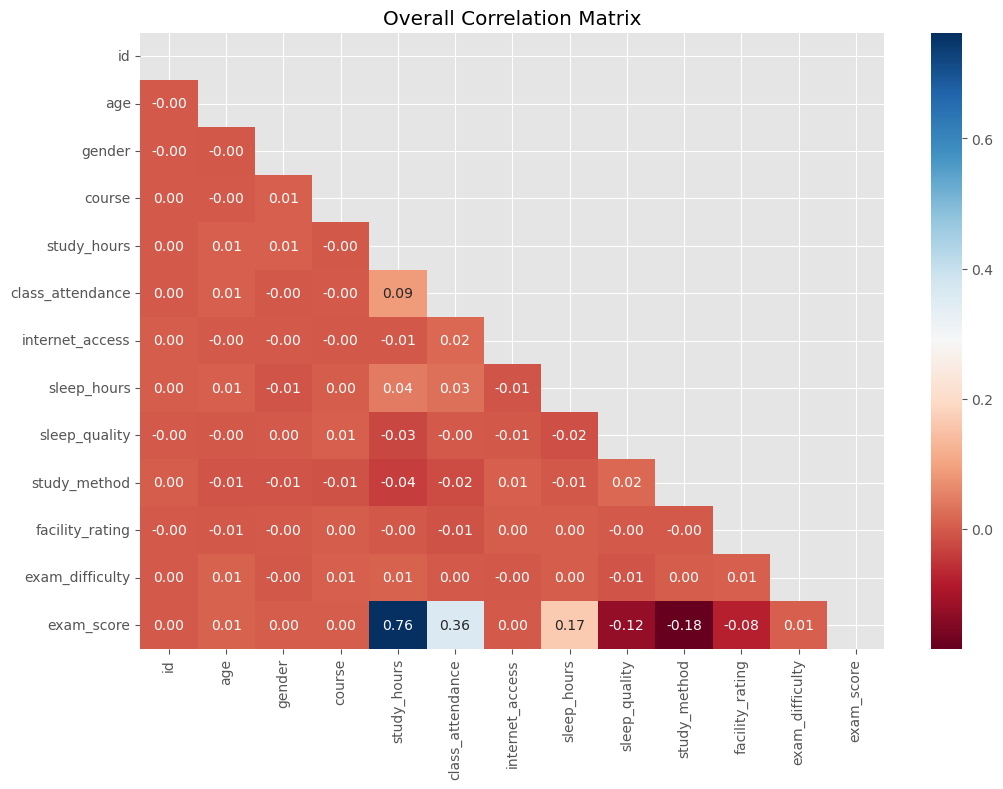

In [9]:
# 4. 전체 변수 상관관계 히트맵 (Heatmap)
# 모든 변수를 숫자로 바꿔서 한눈에 상관관계를 비교
eda_df = train_df.copy()
le = LabelEncoder()
for col in eda_df.select_dtypes(include=['object']).columns:
    eda_df[col] = le.fit_transform(eda_df[col])

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(eda_df.corr(), dtype=bool))
sns.heatmap(eda_df.corr(), annot=True, fmt='.2f', cmap='RdBu', mask=mask)
plt.title('Overall Correlation Matrix')
plt.show()